# Signal Model Comparative Analysis

This notebook demonstrates the usage of the `SignalModelComparator` class to compare various regression models for signal parameter prediction from 1D arrays.

In [1]:
import sys
import os
import numpy as np
import pandas as pd

# Add src to path if needed (if running from Notebook folder)
src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.append(src_path)

from comparative_analysis import SignalModelComparator

## 1. Data Preparation
We generate a synthetic dataset with known amplitudes and frequencies for demonstration purposes.

In [4]:
def generate_demo_data(num_samples=200, length=256):
    data = []
    amplitudes = np.random.uniform(0.5, 3.0, num_samples)
    frequencies = np.random.uniform(1, 15, num_samples)
    t = np.linspace(0, 1, length)
    
    for i in range(num_samples):
        amp = amplitudes[i]
        freq = frequencies[i]
        # Sine wave with some random noise
        signal = amp * np.sin(2 * np.pi * freq * t) + np.random.normal(0, 0.1, length)
        
        row = {f"signal_{j}": signal[j] for j in range(length)}
        row["amplitude"] = amp
        row["frequency"] = freq
        data.append(row)
        
    return pd.DataFrame(data)

print("Generating synthetic dataset...")
df = generate_demo_data()
print(f"Dataset shape: {df.shape}")
df.head()

Generating synthetic dataset...
Dataset shape: (200, 258)


,signal_0,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9,...,signal_248,signal_249,signal_250,signal_251,signal_252,signal_253,signal_254,signal_255,amplitude,frequency
0,-0.023306,0.534779,0.931255,1.455408,1.811965,1.886511,1.726831,1.504746,1.380629,0.783117,...,-1.786968,-1.520325,-0.941077,-0.527679,-0.077669,0.551786,1.022668,1.530583,1.884140,12.144850
1,0.034440,0.115937,0.499362,0.597553,0.791055,1.115080,1.033733,1.064916,1.027379,0.873058,...,1.027801,1.061722,0.824938,0.816782,0.687217,0.221666,0.032976,-0.183288,1.135060,10.536697
2,-0.006796,0.189424,0.414509,0.495592,0.658987,0.837098,1.180155,1.052512,1.387678,1.606866,...,-0.959289,-0.904930,-1.000733,-1.284511,-1.352994,-1.430105,-1.465158,-1.641656,1.891463,3.678513
3,-0.161182,0.241545,0.437660,0.577785,0.668528,0.936778,1.020772,1.032263,1.319086,1.572737,...,0.739979,0.604170,0.302607,0.069050,-0.131446,-0.289671,-0.481549,-0.798570,2.209839,3.545516
4,-0.082117,0.782721,1.232909,1.701984,2.080414,2.191926,1.753018,1.637676,1.087714,0.240257,...,-0.918238,-0.238053,0.514500,1.195029,1.796556,2.005669,1.947283,2.061917,2.104925,13.298795


## 2. Model Comparison
Initialize the comparator and train all models (**Classical ML** + **1D CNN**).

In [5]:
# Initialize for Amplitude prediction
comparator = SignalModelComparator(df, target_col="amplitude")

# Train classical models (Linear, Ridge, SVR, RandomForest, GradientBoosting, XGBoost)
comparator.train_classical_models()

# Train the 1D CNN using PyTorch for 50 epochs
comparator.train_pytorch_cnn(epochs=50)

--- Training Classical Models for amplitude ---
Evaluating LinearRegression...
Evaluating Ridge...
Evaluating SVR...
Evaluating RandomForest...
Evaluating GradientBoosting...
Evaluating XGBoost...
--- Training 1D CNN for amplitude ---
Epoch 10/50, Loss: 0.031003
Epoch 20/50, Loss: 0.007627
Epoch 30/50, Loss: 0.004514
Epoch 40/50, Loss: 0.003804
Epoch 50/50, Loss: 0.003602


## 3. Results Analysis
View the performance summary and visualize the results.


--- Model Comparison Summary ---
           Model  Test R2  Test MAE  Test RMSE
LinearRegression 0.999669  0.011538   0.014044
           Ridge 0.999535  0.013893   0.016653
    RandomForest 0.999216  0.016598   0.021621
GradientBoosting 0.999203  0.016610   0.021804
         XGBoost 0.997596  0.030710   0.037873
     PyTorch_CNN 0.993621  0.049683   0.061691
             SVR 0.987766  0.065352   0.085429


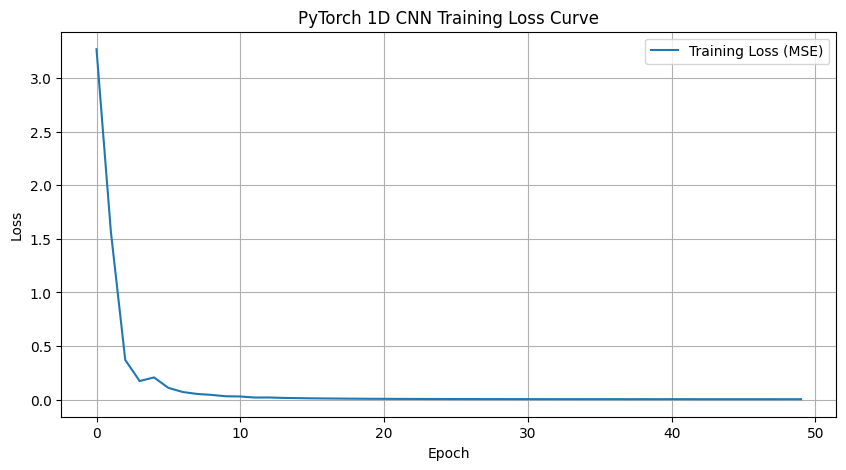

Plotting Predictions for Best Model: LinearRegression


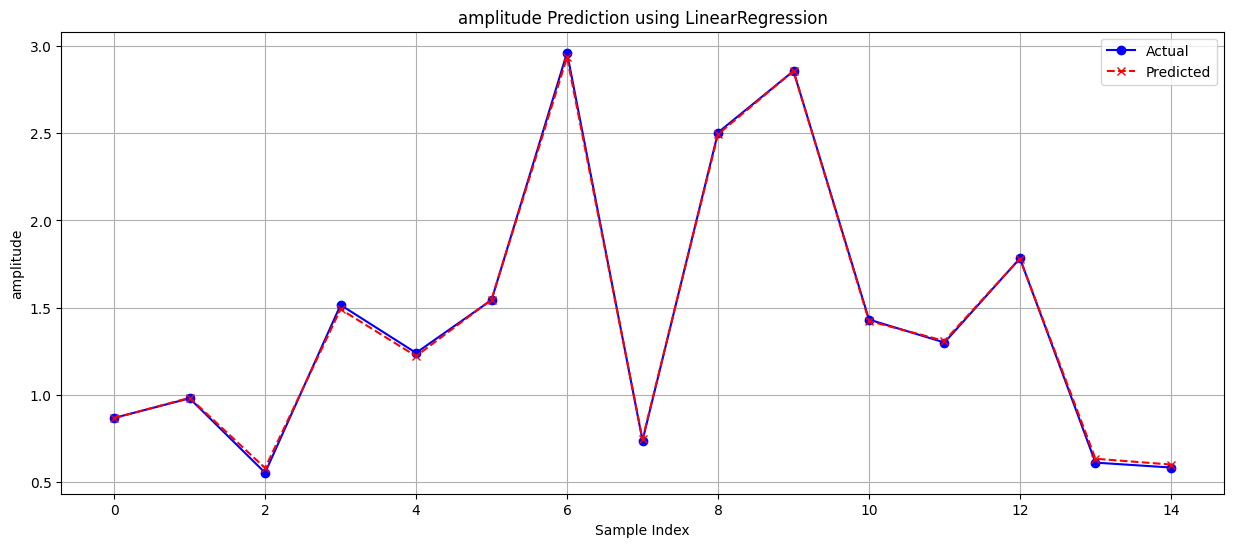

In [6]:
# Print ranked summary table (Test R2, MAE, RMSE)
summary = comparator.print_summary()

# Visualize the CNN training loss curve
comparator.plot_cnn_loss()

# Plot original signals vs predictions for the best performing model
comparator.plot_best_model(num_samples=15)